# 水素分子のための変分量子固有値ソルバー（VQE）

このチュートリアルでは、水素分子（H₂）の基底状態エネルギーを求めるための変分量子固有値ソルバー（VQE）アルゴリズムの実装について解説します。分子ハミルトニアンの生成にはOpenFermion、量子回路の構築にはQamomile、量子シミュレーションにはQiskitなど、さまざまな量子コンピューティングフレームワークを使用します。

ワークフローは以下の通りです：
1. 分子ハミルトニアンを量子ビット演算子へ変換
2. パラメータ化された量子回路（アンザッツ）の作成
3. VQEによる最適化の実装
4. 原子間距離ごとのエネルギー地形の解析

量子コンピューティングを用いて量子化学の問題を解く方法を示し、特にH₂分子の最小エネルギー構造の探索に焦点を当てます。

In [1]:
# 必要なパッケージは以下のコマンドでインストールできます
# !pip install openfermion pyscf openfermionpyscf

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import openfermion.chem as of_chem
import openfermion.transforms as of_trans
import openfermionpyscf as of_pyscf
from qiskit_aer.primitives import EstimatorV2
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm.basic import ry_layer, rz_layer
from qamomile.qiskit import QiskitTranspiler
from qamomile.qiskit.transpiler import QiskitExecutor

## 水素分子のハミルトニアンの作成

In [3]:
basis = "sto-3g"
multiplicity = 1
charge = 0
distance = 0.977
geometry = [["H", [0, 0, 0]], ["H", [0, 0, distance]]]
description = "tmp"
molecule = of_chem.MolecularData(geometry, basis, multiplicity, charge, description)
molecule = of_pyscf.run_pyscf(molecule, run_scf=True, run_fci=True)
n_qubit = molecule.n_qubits
n_electron = molecule.n_electrons
fermionic_hamiltonian = of_trans.get_fermion_operator(molecule.get_molecular_hamiltonian())
jw_hamiltonian = of_trans.jordan_wigner(fermionic_hamiltonian)

## Qamomile ハミルトニアンへの変換

このセクションでは、OpenFermionのハミルトニアンをQamomileフォーマットに変換する。 まず、Jordan-Wigner変換を適用してフェルミ粒子演算子を量子ビット演算子へ変換し、その後、カスタム変換関数を用いてQamomileに適したハミルトニアン表現を作成する。

In [4]:
def operator_to_qamomile(operators: tuple[tuple[int, str], ...]) -> qm_o.Hamiltonian:
    pauli = {"X": qm_o.X, "Y": qm_o.Y, "Z": qm_o.Z}
    H = qm_o.Hamiltonian()
    H.constant = 1.0
    for ope in operators:
        H = H * pauli[ope[1]](ope[0])
    return H

def openfermion_to_qamomile(of_h) -> qm_o.Hamiltonian:
    H = qm_o.Hamiltonian()
    for k, v in of_h.terms.items():
        if len(k) == 0:
            H.constant += v
        else:
            H += operator_to_qamomile(k) * v
    return H

hamiltonian = openfermion_to_qamomile(jw_hamiltonian)

## VQE アンザッツの作成

このセクションでは、VQEアルゴリズムのための EfficientSU2 アンザッツを `@qkernel` デコレータを用いて作成する。 アンザッツとは、試行波動関数を準備するパラメータ付き量子回路である。 `ry_layer`、`rz_layer` および線形 CX エンタングル層を組み合わせて構築し、最後に `expval` でハミルトニアンの期待値を計算する。

In [5]:
@qmc.qkernel
def cx_entangling_layer(q: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    """Linear CX entangling layer."""
    n = q.shape[0]
    for i in qmc.range(n - 1):
        q[i], q[i + 1] = qmc.cx(q[i], q[i + 1])
    return q


@qmc.qkernel
def vqe_ansatz(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
    H: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(n, name="q")
    for r in qmc.range(reps):
        base = r * 2 * n
        q = ry_layer(q, thetas, base)
        q = rz_layer(q, thetas, base + n)
        q = cx_entangling_layer(q)
    # Final rotation layer
    final_base = reps * 2 * n
    q = ry_layer(q, thetas, final_base)
    q = rz_layer(q, thetas, final_base + n)
    return qmc.expval(q, H)

## Qiskitを用いたVQEの実行

このセクションでは、`QiskitTranspiler` を使って VQE カーネルをトランスパイルし、Qiskit Aer シミュレータ上で実行する。`expval` による期待値計算はトランスパイラが自動的に処理するため、ユーザーは最適化ループのみ実装すればよい。もちろん、他の量子コンピューティングフレームワークを使用することも可能である。

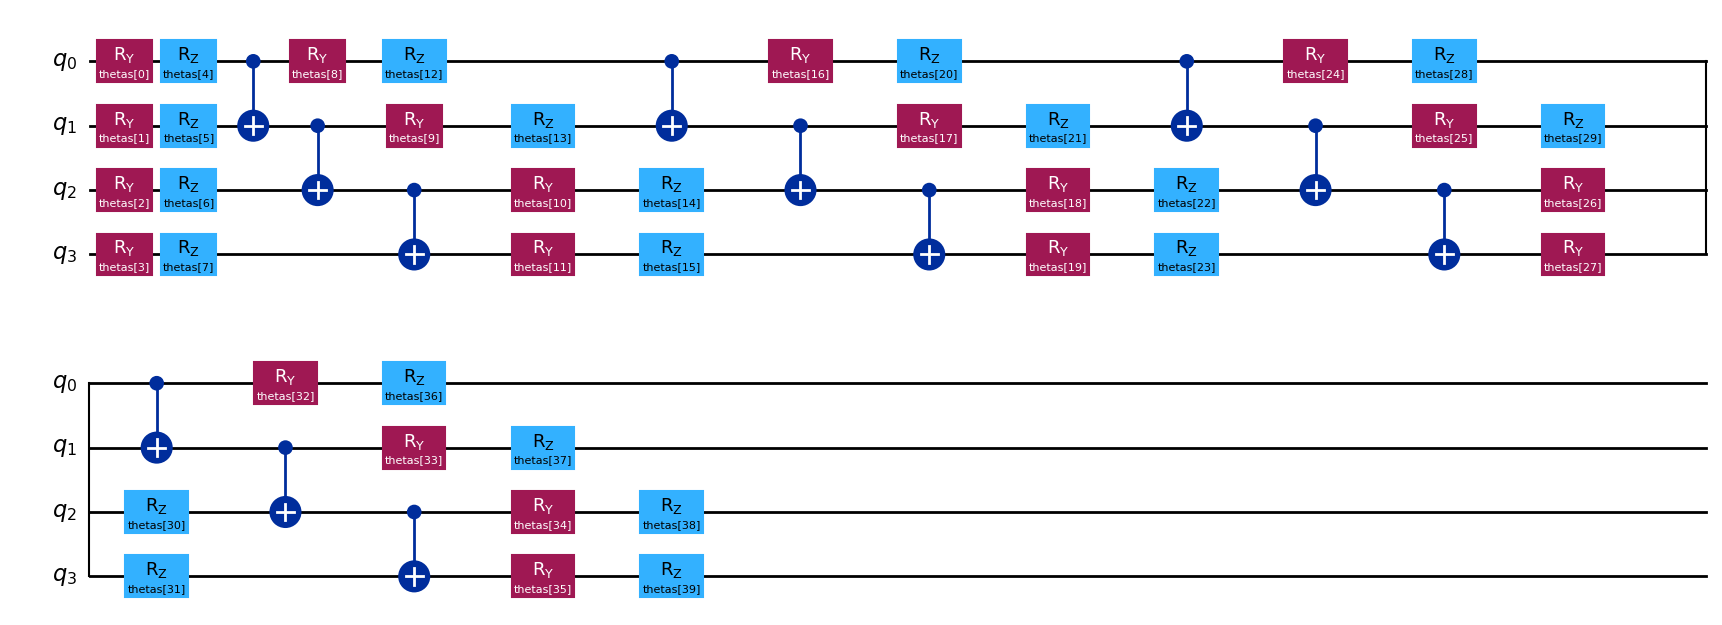

In [6]:
transpiler = QiskitTranspiler()
reps = 4

executable = transpiler.transpile(
    vqe_ansatz,
    bindings={"n": n_qubit, "reps": reps, "H": hamiltonian},
    parameters=["thetas"],
)

# Transpiled quantum circuit
executable.quantum_circuit.draw("mpl")

In [7]:
cost_history = []
executor = QiskitExecutor(estimator=EstimatorV2())


def cost_fn(param_values):
    job = executable.run(executor, bindings={"thetas": list(param_values)})
    return job.result()


def cost_callback(param_values):
    cost_history.append(cost_fn(param_values))


num_params = len(executable.parameter_names)
initial_params = np.random.uniform(0, np.pi, num_params)

# VQE 最適化を実行する
result = minimize(
    cost_fn,
    initial_params,
    method="BFGS",
    options={"disp": True, "maxiter": 50, "gtol": 1e-6},
    callback=cost_callback,
)
print(result)

         Current function value: -1.105891
         Iterations: 50
         Function evaluations: 2091
         Gradient evaluations: 51
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: -1.1058908052662584
        x: [ 1.631e+00  2.787e+00 ...  1.762e+00  2.874e-01]
      nit: 50
      jac: [-2.402e-04 -2.867e-04 ...  2.117e-04  2.075e-04]
 hess_inv: [[ 5.310e+01 -2.083e+01 ... -7.941e+00 -8.610e+00]
            [-2.083e+01  1.219e+01 ...  2.907e+00  3.064e+00]
            ...
            [-7.941e+00  2.907e+00 ...  2.366e+00  1.447e+00]
            [-8.610e+00  3.064e+00 ...  1.447e+00  2.702e+00]]
     nfev: 2091
     njev: 51


/Users/masakishiraishi/projects/jij/Qamomile/.venv/lib/python3.12/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


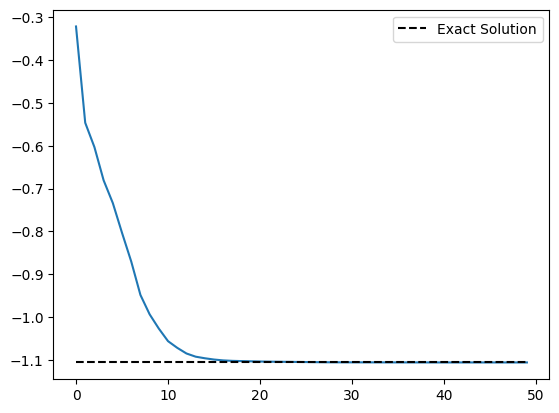

In [8]:
plt.plot(cost_history)
plt.plot(
    range(len(cost_history)),
    [molecule.fci_energy] * len(cost_history),
    linestyle="dashed",
    color="black",
    label="Exact Solution",
)
plt.legend()
plt.show()

## 原子同士の距離を変更する

In [9]:
def hydrogen_molecule(bond_length):
    basis = "sto-3g"
    multiplicity = 1
    charge = 0
    geometry = [["H", [0, 0, 0]], ["H", [0, 0, bond_length]]]
    description = "tmp"
    molecule = of_chem.MolecularData(geometry, basis, multiplicity, charge, description)
    molecule = of_pyscf.run_pyscf(molecule, run_scf=True, run_fci=True)
    fermionic_hamiltonian = of_trans.get_fermion_operator(
        molecule.get_molecular_hamiltonian()
    )
    jw_hamiltonian = of_trans.jordan_wigner(fermionic_hamiltonian)
    return openfermion_to_qamomile(jw_hamiltonian), molecule.fci_energy

bond_lengths = np.linspace(0.2, 1.5, 15)
energies = []
for bond_length in bond_lengths:
    hamiltonian, fci_energy = hydrogen_molecule(bond_length)

    executable = transpiler.transpile(
        vqe_ansatz,
        bindings={"n": hamiltonian.num_qubits, "reps": reps, "H": hamiltonian},
        parameters=["thetas"],
    )

    num_params = len(executable.parameter_names)
    initial_params = np.random.uniform(0, np.pi, num_params)
    result = minimize(
        cost_fn,
        initial_params,
        method="BFGS",
        options={"maxiter": 50, "gtol": 1e-6},
    )

    energies.append(result.fun)

    print("distance: ", bond_length, "energy: ", result.fun, "fci_energy: ", fci_energy)

distance:  0.2 energy:  0.15748797659981106 fci_energy:  0.15748213479836526


distance:  0.29285714285714287 energy:  -0.565830349774729 fci_energy:  -0.5679447209710013


distance:  0.38571428571428573 energy:  -0.8824107447921492 fci_energy:  -0.8833596636183383


distance:  0.4785714285714286 energy:  -1.0335968047013606 fci_energy:  -1.0336011797110967


distance:  0.5714285714285714 energy:  -1.1038181376471399 fci_energy:  -1.1042094222435166


...

distance:  1.1285714285714286 energy:  -1.072722130537506 fci_energy:  -1.0727578805453502


distance:  1.2214285714285713 energy:  -1.0512432606570343 fci_energy:  -1.052008162170845


distance:  1.3142857142857143 energy:  -1.0322292717281094 fci_energy:  -1.0322400306247084


distance:  1.4071428571428573 energy:  -1.0141470586435453 fci_energy:  -1.0141470586695496


distance:  1.5 energy:  -0.998112850499435 fci_energy:  -0.9981493534714101


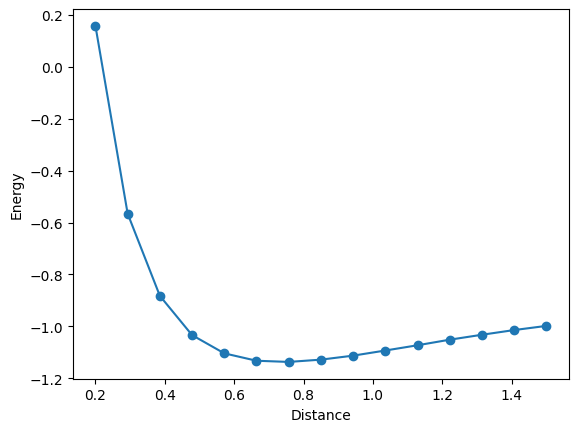

In [10]:
plt.plot(bond_lengths, energies, "-o")
plt.xlabel("Distance")
plt.ylabel("Energy")
plt.show()